# Chapter 75 — Recursion and Mathematical Functions

> **Prerequisites:** ch052 (Functions as Programs), ch074 (Iterative Computation)
>
> **You will learn:**
> - Define recursive mathematical sequences and functions
> - Implement recursion efficiently with memoization
> - Understand the connection between recursion and mathematical induction
> - Analyze recursive function complexity
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

**Recursion** defines a function in terms of itself on a simpler input. In mathematics, this is called a **recurrence relation**.

Examples:
- Factorial: n! = n·(n-1)!, 0! = 1
- Fibonacci: F(n) = F(n-1) + F(n-2), F(0)=0, F(1)=1
- Power: aⁿ = a·aⁿ⁻¹, a⁰ = 1
- GCD: gcd(a, b) = gcd(b, a mod b), gcd(a, 0) = a

Every recursive function has:
1. **Base case(s)**: the non-recursive terminating condition
2. **Recursive case**: reduces to smaller inputs

**Connection to mathematical induction:**
- Induction: prove P(0); assume P(n-1), prove P(n)
- Recursion: define f(0) = base; define f(n) in terms of f(n-1)

These are the same structure — recursion is induction made computational.

**Performance:** Naive recursion may recompute the same subproblem exponentially many times. Memoization (ch052) caches results, turning exponential time to linear.

---

## 2. Intuition & Mental Models

**Physical analogy:** Russian nesting dolls (Matryoshka). To know the innermost doll, you open each doll in sequence. The recursive structure is: "this doll contains one smaller doll." The base case is: "the smallest doll is solid."

**Computational analogy:** Merge sort is recursive: sort left half, sort right half, merge. The base case is a single-element array. Tree traversal is recursive: process root, recursively process left subtree, recursively process right subtree.

---

## 3. Visualization

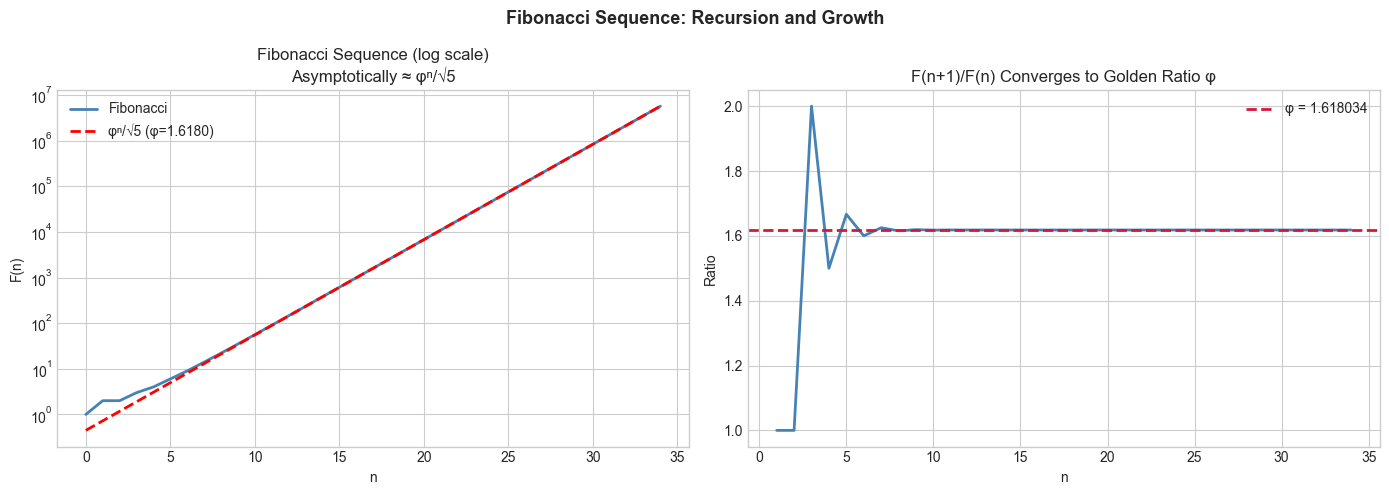

In [1]:
# --- Visualization: Fibonacci growth and recursion tree ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

from functools import lru_cache

@lru_cache(maxsize=None)
def fib(n):
    if n <= 1: return n
    return fib(n-1) + fib(n-2)

n_vals = np.arange(0, 35)
fib_vals = np.array([fib(n) for n in n_vals])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fibonacci values vs exponential growth
axes[0].semilogy(n_vals, fib_vals + 1, color='steelblue', linewidth=2, label='Fibonacci')
phi = (1 + np.sqrt(5)) / 2  # golden ratio
axes[0].semilogy(n_vals, phi**n_vals / np.sqrt(5), 'r--', linewidth=2, label=f'φⁿ/√5 (φ={phi:.4f})')
axes[0].set_title('Fibonacci Sequence (log scale)\nAsymptotically ≈ φⁿ/√5')
axes[0].set_xlabel('n'); axes[0].set_ylabel('F(n)'); axes[0].legend()

# Golden ratio convergence: F(n+1)/F(n) → φ
ratios = fib_vals[1:] / fib_vals[:-1].astype(float).clip(1)
axes[1].plot(n_vals[1:], ratios, color='steelblue', linewidth=2)
axes[1].axhline(phi, color='crimson', linestyle='--', linewidth=2, label=f'φ = {phi:.6f}')
axes[1].set_title('F(n+1)/F(n) Converges to Golden Ratio φ')
axes[1].set_xlabel('n'); axes[1].set_ylabel('Ratio'); axes[1].legend()

plt.suptitle('Fibonacci Sequence: Recursion and Growth', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 5. Python Implementation

In [2]:
# --- Implementation: Recursive functions with complexity analysis ---
import numpy as np
import time
from functools import lru_cache

def power_naive(a, n):
    """Naive power: a^n in O(n) multiplications."""
    if n == 0: return 1
    return a * power_naive(a, n-1)

def power_fast(a, n):
    """Fast power (repeated squaring): a^n in O(log n) multiplications.
    Uses: a^n = (a^(n/2))² if n even; a * a^(n-1) if n odd.
    """
    if n == 0: return 1
    if n % 2 == 0:
        half = power_fast(a, n // 2)
        return half * half
    return a * power_fast(a, n - 1)

# Benchmark
a, n = 2, 1000

t0 = time.time()
result_naive = power_naive(a, n)
t_naive = time.time() - t0

t0 = time.time()
result_fast = power_fast(a, n)
t_fast = time.time() - t0

print(f"power_naive(2, 1000) == power_fast(2, 1000): {result_naive == result_fast}")
print(f"Naive time: {t_naive*1e6:.1f} μs")
print(f"Fast time:  {t_fast*1e6:.1f} μs")
print(f"Speedup: ~{t_naive/max(t_fast, 1e-9):.0f}x")

# For n=10000, fast is crucial
print(f"\n2^10000 mod 1000 (naive too slow, fast ok):")
print(power_fast(2, 10000) % 1000)

power_naive(2, 1000) == power_fast(2, 1000): True
Naive time: 705.2 μs
Fast time:  83.0 μs
Speedup: ~8x

2^10000 mod 1000 (naive too slow, fast ok):
376


---

## 6. Experiments

**Experiment 1:** Time naive vs memoized Fibonacci for n=5, 10, 20, 30, 40. Plot time vs n. What's the growth rate of naive? (Exponential — 2^n roughly.) What about memoized? (Linear.)

**Experiment 2:** Implement the Tower of Hanoi recursively. Count how many moves it takes for n=1, 2, 3, ..., 15 disks. Verify the pattern is 2^n - 1.

---

## 7. Exercises

**Easy 1.** Implement factorial(n) recursively. What is factorial(0), factorial(5), factorial(10)?

**Easy 2.** The Collatz sequence: if n is even, halve it; if odd, triple and add 1. Repeat until you reach 1. Implement recursively and count the steps for n=27.

**Medium 1.** Implement recursive merge sort. Verify it correctly sorts random arrays and measure its O(n log n) time complexity by timing on n=100, 1000, 10000 elements.

**Medium 2.** Implement a recursive function to compute the nth Catalan number: C(0)=1, C(n)=Σᵢ C(i)·C(n-1-i). These count the number of ways to fully parenthesize n+1 factors. Compute C(0) through C(10).

**Hard.** Implement memoized top-down dynamic programming for the longest common subsequence (LCS) problem. LCS(s1, s2) is defined recursively: if last chars match, 1+LCS(s1[:-1], s2[:-1]); else max(LCS(s1[:-1], s2), LCS(s1, s2[:-1])). Test on pairs of strings.

---

## 9. Chapter Summary & Connections

- Recursion = base case + reduction to smaller input; structurally identical to mathematical induction
- Memoization converts exponential-time recursion to linear-time (when subproblems repeat)
- Fast exponentiation: O(log n) via repeated squaring — a classic recursion optimization
- Fibonacci → golden ratio: the recursive structure reveals a deep algebraic constant

**Forward connections:**
- Recursive neural networks (RNNs) apply the same function at each time step — ch178
- Recursive matrix algorithms (Strassen, LU decomposition with pivoting) reuse this structure
- ch076 (Discrete Dynamical Systems) generalizes recursion to systems of equations